### Импорт библиотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf

# Для воспроизводимости результатов
np.random.seed(42)
tf.random.set_seed(42)

### Загрузка файла в Colab

In [ ]:
uploaded = files.upload()

Saving traffic_dataset_with_trend.csv to traffic_dataset_with_trend.csv


### Чтение датасета

In [ ]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Имя файла:", filename)
print("Размер датасета:", df.shape)

df.head()

Имя файла: traffic_dataset_with_trend.csv
Размер датасета: (8736, 4)


,Timestamp,Weather,Events,Traffic Volume
0,2023-01-01 00:00:00,Cloudy,False,803.0
1,2023-01-01 01:00:00,Clear,False,861.0
2,2023-01-01 02:00:00,Clear,False,582.0
3,2023-01-01 03:00:00,Cloudy,False,236.0
4,2023-01-01 04:00:00,Cloudy,False,569.0


### Первичный анализ данных

In [ ]:
print("Названия столбцов:")
print(df.columns.tolist())

print("\nТипы данных:")
print(df.dtypes)

print("\nКоличество пропусков:")
print(df.isna().sum())

print("\nОбщая информация:")
print(df.info())

Названия столбцов:
['Timestamp', 'Weather', 'Events', 'Traffic Volume']

Типы данных:
Timestamp          object
Weather            object
Events               bool
Traffic Volume    float64
dtype: object

Количество пропусков:
Timestamp         0
Weather           0
Events            0
Traffic Volume    0
dtype: int64

Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8736 entries, 0 to 8735
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Timestamp       8736 non-null   object 
 1   Weather         8736 non-null   object 
 2   Events          8736 non-null   bool   
 3   Traffic Volume  8736 non-null   float64
dtypes: bool(1), float64(1), object(2)
memory usage: 213.4+ KB
None


### Преобразование даты и сортировка

In [ ]:
time_col = 'Timestamp'
target_col = 'Traffic Volume'
weather_col = 'Weather'
events_col = 'Events'

print("Временной столбец:", time_col)
print("Целевой столбец:", target_col)
print("Категориальный признак:", weather_col)
print("Булев признак:", events_col)

df[time_col] = pd.to_datetime(df[time_col], errors='coerce')

# Удаляем строки, где дата не преобразовалась
df = df.dropna(subset=[time_col])

# Сортируем по времени
df = df.sort_values(by=time_col).reset_index(drop=True)

print(df.head())
print(df.tail())

Временной столбец: Timestamp
Целевой столбец: Traffic Volume
Категориальный признак: Weather
Булев признак: Events
            Timestamp Weather  Events  Traffic Volume
0 2023-01-01 00:00:00  Cloudy   False           803.0
1 2023-01-01 01:00:00   Clear   False           861.0
2 2023-01-01 02:00:00   Clear   False           582.0
3 2023-01-01 03:00:00  Cloudy   False           236.0
4 2023-01-01 04:00:00  Cloudy   False           569.0
               Timestamp Weather  Events  Traffic Volume
8731 2023-12-30 19:00:00  Cloudy   False          1118.0
8732 2023-12-30 20:00:00   Clear   False          1681.0
8733 2023-12-30 21:00:00  Cloudy   False           833.0
8734 2023-12-30 22:00:00   Clear   False           740.0
8735 2023-12-30 23:00:00   Clear   False           825.0


### Создание временных признаков

In [ ]:
df['hour'] = df[time_col].dt.hour
df['dayofweek'] = df[time_col].dt.dayofweek
df['month'] = df[time_col].dt.month
df['day'] = df[time_col].dt.day
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

print(df[['Timestamp', 'hour', 'dayofweek', 'month', 'day', 'is_weekend']].head())

            Timestamp  hour  dayofweek  month  day  is_weekend
0 2023-01-01 00:00:00     0          6      1    1           1
1 2023-01-01 01:00:00     1          6      1    1           1
2 2023-01-01 02:00:00     2          6      1    1           1
3 2023-01-01 03:00:00     3          6      1    1           1
4 2023-01-01 04:00:00     4          6      1    1           1


### Кодирование признаков Weather и Events

In [ ]:
# Булев признак переводим в 0 и 1
df[events_col] = df[events_col].astype(int)

# Кодируем погодные условия
df = pd.get_dummies(df, columns=[weather_col], drop_first=True)

print("Новые столбцы после кодирования:")
print(df.columns.tolist())

Новые столбцы после кодирования:
['Timestamp', 'Events', 'Traffic Volume', 'hour', 'dayofweek', 'month', 'day', 'is_weekend', 'Weather_Cloudy', 'Weather_Rain', 'Weather_Snow']


### Формирование списка признаков

In [ ]:
weather_encoded_cols = [col for col in df.columns if col.startswith('Weather_')]

feature_cols = [
    target_col,
    events_col,
    'hour',
    'dayofweek',
    'month',
    'day',
    'is_weekend'
] + weather_encoded_cols

data_model = df[feature_cols].copy()

print("Используемые признаки:")
print(feature_cols)

print("\nРазмер итоговой таблицы признаков:")
print(data_model.shape)

data_model.head()

Используемые признаки:
['Traffic Volume', 'Events', 'hour', 'dayofweek', 'month', 'day', 'is_weekend', 'Weather_Cloudy', 'Weather_Rain', 'Weather_Snow']

Размер итоговой таблицы признаков:
(8736, 10)


,Traffic Volume,Events,hour,dayofweek,month,day,is_weekend,Weather_Cloudy,Weather_Rain,Weather_Snow
0,803.0,0,0,6,1,1,1,True,False,False
1,861.0,0,1,6,1,1,1,False,False,False
2,582.0,0,2,6,1,1,1,False,False,False
3,236.0,0,3,6,1,1,1,True,False,False
4,569.0,0,4,6,1,1,1,True,False,False


### Масштабирование данных

In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_model)

print("Размер масштабированных данных:", scaled_data.shape)

Размер масштабированных данных: (8736, 10)


### Создание последовательностей

In [ ]:
def create_sequences(data, target_index, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length, target_index])
    return np.array(X), np.array(y)

target_index = feature_cols.index(target_col)
SEQ_LENGTH = 24

X, y = create_sequences(scaled_data, target_index, seq_length=SEQ_LENGTH)

print("Форма X:", X.shape)
print("Форма y:", y.shape)

Форма X: (8712, 24, 10)
Форма y: (8712,)


### Разделение на train/test

In [ ]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (6969, 24, 10)
X_test: (1743, 24, 10)
y_train: (6969,)
y_test: (1743,)


### Функция построения моделей

In [ ]:
def build_model(model_type, input_shape):
    model = Sequential()

    if model_type == 'RNN':
        model.add(SimpleRNN(64, input_shape=input_shape))
    elif model_type == 'LSTM':
        model.add(LSTM(64, input_shape=input_shape))
    elif model_type == 'GRU':
        model.add(GRU(64, input_shape=input_shape))
    else:
        raise ValueError("Неизвестный тип модели")

    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')
    return model

### Блоки обучения моделей

EarlyStopping

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

### Обучение SimpleRNN

In [ ]:
rnn_model = build_model('RNN', (X_train.shape[1], X_train.shape[2]))

history_rnn = rnn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0314 - val_loss: 0.0133
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0153 - val_loss: 0.0124
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0135 - val_loss: 0.0121
Epoch 4/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0133 - val_loss: 0.0120
Epoch 5/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0128 - val_loss: 0.0121
Epoch 6/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0127 - val_loss: 0.0121
Epoch 7/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0127 - val_loss: 0.0120
Epoch 8/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0126 - val_loss: 0.0119
Epoch 9/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0125 - val_loss: 0.0121
Epoch 10/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0126 - val_loss: 0.0121
Epoch 11/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0125 - val_loss: 0.0122
Epoch 12/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0

### Обучение LSTM

In [ ]:
lstm_model = build_model('LSTM', (X_train.shape[1], X_train.shape[2]))

history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 0.0158 - val_loss: 0.0122
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0129 - val_loss: 0.0118
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0126 - val_loss: 0.0118
Epoch 4/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0123 - val_loss: 0.0118
Epoch 5/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0123 - val_loss: 0.0120
Epoch 6/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0122 - val_loss: 0.0119
Epoch 7/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0121 - val_loss: 0.0121
Epoch 8/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0121 - val_loss: 0.0122
Epoch 9/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0121 - val_loss: 0.0120


### Обучение GRU

In [ ]:
gru_model = build_model('GRU', (X_train.shape[1], X_train.shape[2]))

history_gru = gru_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0191 - val_loss: 0.0140
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0134 - val_loss: 0.0127
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0129 - val_loss: 0.0125
Epoch 4/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0127 - val_loss: 0.0121
Epoch 5/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0125 - val_loss: 0.0118


### Оценка моделей

In [ ]:
def inverse_transform_target(y_scaled, scaler, feature_count, target_index):
    temp = np.zeros((len(y_scaled), feature_count))
    temp[:, target_index] = y_scaled.reshape(-1)
    return scaler.inverse_transform(temp)[:, target_index]

def evaluate_model(model, X_test, y_test, scaler, feature_count, target_index):
    y_pred_scaled = model.predict(X_test).reshape(-1)

    y_test_real = inverse_transform_target(y_test, scaler, feature_count, target_index)
    y_pred_real = inverse_transform_target(y_pred_scaled, scaler, feature_count, target_index)

    mse = mean_squared_error(y_test_real, y_pred_real)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    r2 = r2_score(y_test_real, y_pred_real)

    return y_test_real, y_pred_real, mse, mae, r2

### Подсчет метрик по всем моделям

In [ ]:
results = {}

for name, model in {
    'SimpleRNN': rnn_model,
    'LSTM': lstm_model,
    'GRU': gru_model
}.items():
    y_test_real, y_pred_real, mse, mae, r2 = evaluate_model(
        model, X_test, y_test, scaler, len(feature_cols), target_index
    )

    results[name] = {
        'MSE': mse,
        'MAE': mae,
        'R2': r2,
        'y_test_real': y_test_real,
        'y_pred_real': y_pred_real
    }

comparison_df = pd.DataFrame({
    model_name: {
        'MSE': values['MSE'],
        'MAE': values['MAE'],
        'R2': values['R2']
    }
    for model_name, values in results.items()
}).T

comparison_df = comparison_df.sort_values(by='MSE')
comparison_df

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


,MSE,MAE,R2
SimpleRNN,520275.416602,417.762847,0.034326
LSTM,530838.753396,475.483731,0.014719
GRU,640249.811508,597.496894,-0.188357


### Графики обучения

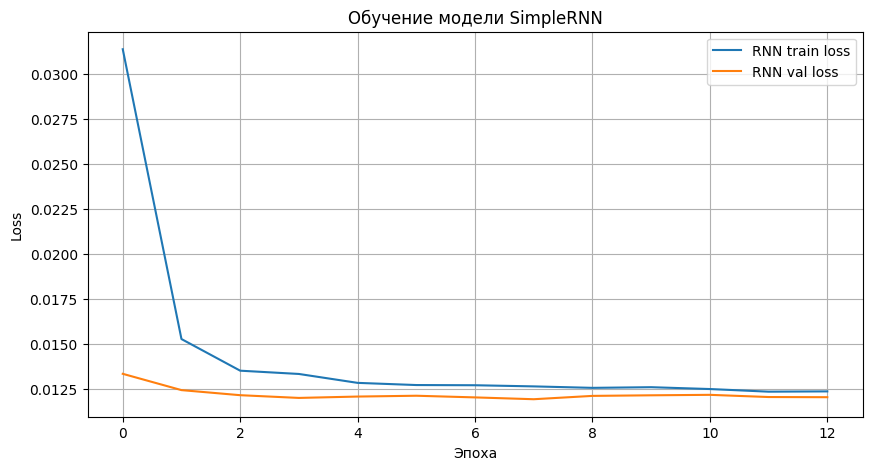

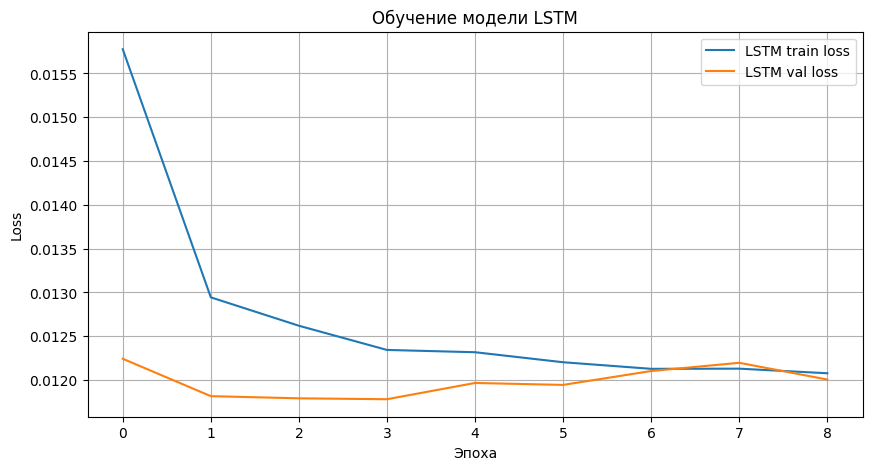

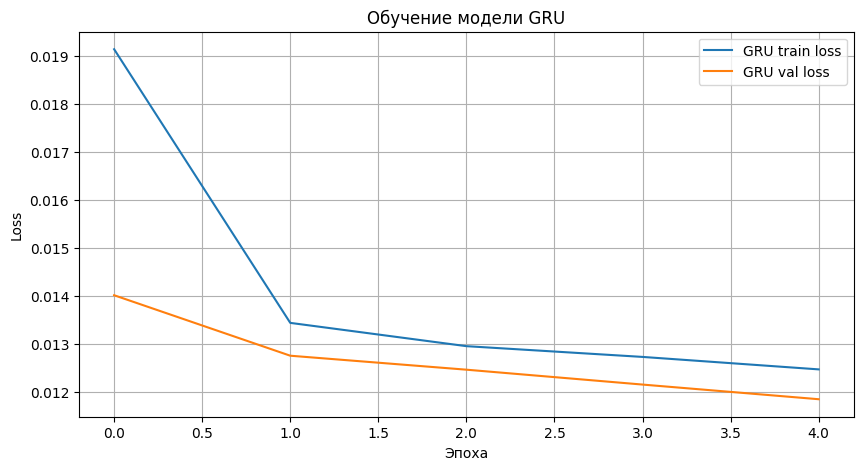

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['loss'], label='RNN train loss')
plt.plot(history_rnn.history['val_loss'], label='RNN val loss')
plt.title('Обучение модели SimpleRNN')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_lstm.history['loss'], label='LSTM train loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM val loss')
plt.title('Обучение модели LSTM')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_gru.history['loss'], label='GRU train loss')
plt.plot(history_gru.history['val_loss'], label='GRU val loss')
plt.title('Обучение модели GRU')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### График реальных и предсказанных значений

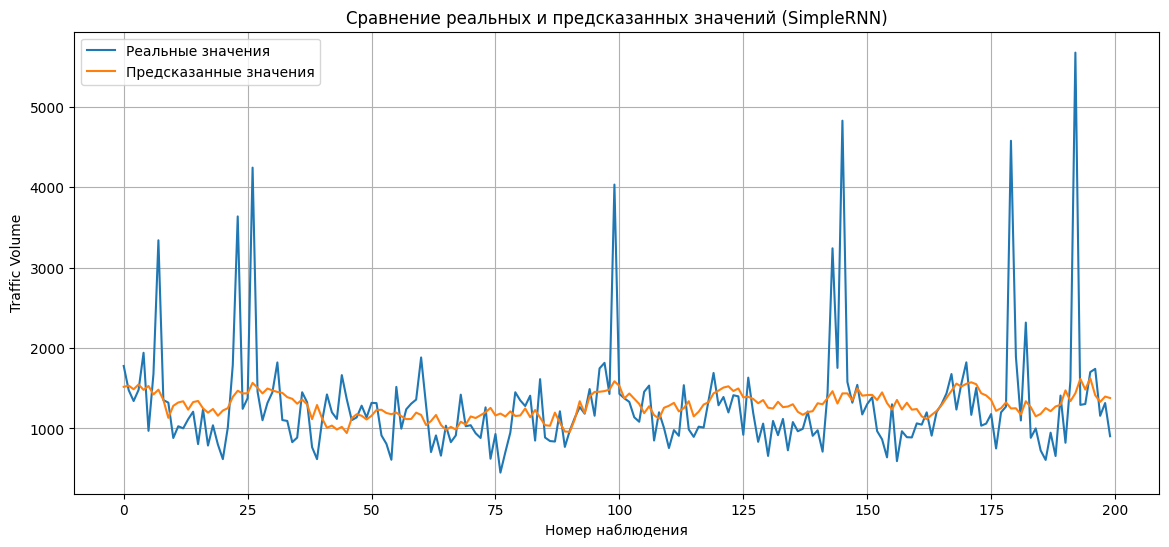

In [ ]:
best_model_name = comparison_df.index[0]
best_y_test = results[best_model_name]['y_test_real']
best_y_pred = results[best_model_name]['y_pred_real']

plt.figure(figsize=(14, 6))
plt.plot(best_y_test[:200], label='Реальные значения')
plt.plot(best_y_pred[:200], label='Предсказанные значения')
plt.title(f'Сравнение реальных и предсказанных значений ({best_model_name})')
plt.xlabel('Номер наблюдения')
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.show()